# Imports

In [ ]:
%reload_ext autoreload
%autoreload 2


from stnd.utility.data_utils import make_or_load_from_cache
from stnd.utility.utils import apply_random_seed
import sys
import os
import sklearn
import numpy as np
import pandas as pd

ROOT_PATH = os.path.join(os.path.dirname(os.path.abspath("")))
sys.path.insert(0, ROOT_PATH)
from experiments import (
    RANDOM_SEED,
    make_train_test_model_embeddings,
    make_cache_subpath,
    make_disagreement_scores_dict,
    make_fitted_weights
)
from utils import (
    lb_scenarios,
    dump_pickle,
    load_pickle,
    prepare_and_split_data
)
from plots import (
    MODEL_OUTPUTS_PATH,
    load_scores,
    safe_spearmanr
)
from selection import sample_items
from run_experiment import load_and_split_model_outputs
from acc import (
    compute_true_acc,
    compute_acc_knn
)
from scripts.evaluate_mmlu import evaluate_mmlu
sys.path.pop(0);

# Evaluate new model

## Get ground truth

### Take from leaderboard snapshot

In [ ]:
df = pd.read_csv(os.path.join(ROOT_PATH, "benchmark_csvs","open-llm-leaderboard.csv"))
small_models = df[df['#Params (B)'] <= 8]
small_models.head(n=10)


In [ ]:
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
except:
    print("transformers not installed; run `pip install transformers`")


model_id = "alnrg2arg/test2_4"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

### Eval on the whole dataset to compute ground truth from scratch

In [ ]:
evaluate_mmlu(
    model_id=model_id,
    subset="all",
    num_fewshot=5,
    max_samples=None,
    batch_size=4,
)

## DISCO-eval

In [ ]:
# get anchor points
# get predictor
# get outputs for anchor points, cache
# predict with predictor
# compare to ground truth

# Debug

In [ ]:
bench = "mmlu_fields"
data, scenarios, set_of_rows, data_path = load_and_split_model_outputs(
    bench=bench,
    split='noniid',
    model_outputs_path=MODEL_OUTPUTS_PATH,
    text_to_vector=None,
    return_data_path=True,
    subsample_validation=False,
)

chosen_scenarios = list(scenarios.keys())
split_number = 0
rows_to_hide = set_of_rows[split_number]


In [ ]:
print(data['data']['harness_arc_challenge_25']['correctness'].shape)

In [ ]:
(
    scores_train,
    predictions_train,
    predictions_test,
    scores_test,
    balance_weights,
    scenarios_position,
    subscenarios_position,
) = prepare_and_split_data(
    chosen_scenarios,
    scenarios,
    data,
    rows_to_hide=rows_to_hide,
    n_source_models=None,
)

In [ ]:
sampling_names = ["high-disagreement"]
disagreement_type = "pds"
disagreement_scores_dict = make_disagreement_scores_dict(
    config={
        "sampling_names": sampling_names,
        "predictions_train": predictions_train,
        "disagreement_type": disagreement_type,
    }
)

In [ ]:

number_items = [100]
iterations = 5
sampling_name = sampling_names[0]
number_item = number_items[0]
seen_items_dic = {sampling_name: {}}
apply_random_seed(RANDOM_SEED)
samples = sample_items(
    number_item,
    iterations,
    sampling_name,
    chosen_scenarios,
    scenarios,
    subscenarios_position,
    responses_test=scores_test,
    scores_train=scores_train,
    predictions_train=predictions_train,
    scenarios_position=scenarios_position,
    A=None,
    B=None,
    balance_weights=balance_weights,
    disagreement_scores_dict=disagreement_scores_dict,
    skip_irt=True,
)
(
    _,
    seen_items_dic[sampling_name][number_item],
    _,
    _
) = samples

In [ ]:
# load embeddings
# cache_path = ""
# cache = load_pickle(cache_path)
# scenario_name = "mmlu"
# split_number = 0
# emb_cache_path = (
#     make_cache_subpath(
#         cache, scenario_name, split_number, f"embeddings_path"
#     )
# )

pca = 256
apply_softmax_to_predictions = True
(
    train_models_embeddings,
    test_models_embeddings,
) = make_train_test_model_embeddings(
    emb_config={
        "sampling_names": sampling_names,
        "number_items": number_items,
        "iterations": iterations,
        "predictions_train": predictions_train,
        "seen_items_dic": seen_items_dic,
        "predictions_test": predictions_test,
        "seen_items_dic": seen_items_dic,
        "pca": pca,
        "apply_softmax": apply_softmax_to_predictions,
    }
)



# make_or_load_from_cache(
#     object_name="train_test_model_embeddings",
#     object_config={
#         "sampling_names": sampling_names,
#         "number_items": number_items,
#         "iterations": iterations,
#         "predictions_train": predictions_train,
#         "seen_items_dic": seen_items_dic,
#         "predictions_test": predictions_test,
#         "seen_items_dic": seen_items_dic,
#         "pca": pca,
#         "apply_softmax": apply_softmax_to_predictions,
#     },
#     make_func=make_train_test_model_embeddings,
#     cache_path=emb_cache_path,
# )

In [ ]:
train_model_indices = list(range(scores_train.shape[0]))
train_model_true_accs = compute_true_acc(
    scores_train,
    balance_weights,  # sample -> sample weight
    scenarios_position,  # scenario -> list of sample indices
    chosen_scenarios,
    train_model_indices,
    train_model_indices,  # they are not the global indices, but the contiguous indices of train models after removing test models
)

In [ ]:

    # "RandomForestRegressor_100": {
    #     "class_path": "sklearn.ensemble.RandomForestRegressor",
    #     "params": {"n_estimators": 100}
    # },

fitted_model_type = "RandomForestRegressor_100"
chosen_fitting_methods = [
    (fitted_model_type, (sklearn.ensemble.RandomForestRegressor, {"n_estimators": 100}))
]
scenario = bench.split("_")[0]
fitted_weights = make_fitted_weights(
    config={
        "sampling_names": sampling_names,
        "number_items": number_items,
        "iterations": iterations,
        "train_models_embeddings": train_models_embeddings,
        "train_model_true_accs": train_model_true_accs,
        "scenario": scenario,
        "cache_path": "./cache_for_notebook",
        "chosen_fitting_methods": chosen_fitting_methods,
        "skip_iterations_when_fixed_sampling": False,
    }
)

# make_or_load_from_cache(
#     object_name="fitted_weights",
#     object_config={
#         "sampling_names": sampling_names,
#         "number_items": number_items,
#         "iterations": iterations,
#         "train_models_embeddings": train_models_embeddings,
#         "train_model_true_accs": train_model_true_accs,
#         "scenario": bench,
#         "cache_path": fitted_weights_cache_path,
#         "chosen_fitting_methods": chosen_fitting_methods,
#     },
#     make_func=make_fitted_weights,
#     cache_path=fitted_weights_cache_path,
# )

In [ ]:
predictors_per_seed = fitted_weights[sampling_names[0]][100]
target_model_embeddings_per_seed = test_models_embeddings[sampling_names[0]][100]
predicted_accs = {}
predicted_accs_knn = {}
for seed in range(iterations):
    fitted_model = predictors_per_seed[seed][fitted_model_type]
    target_model_embeddings = target_model_embeddings_per_seed[seed]
    for target_model_idx in range(target_model_embeddings.shape[0]):
        test_model_embedding = target_model_embeddings[target_model_idx]
        fitted_acc = fitted_model.predict(
            test_model_embedding.numpy().reshape(1, -1)
        )[0]
        fitted_acc_knn = compute_acc_knn(
            test_model_embedding=test_model_embedding,
            train_model_embeddings=train_models_embeddings[
                sampling_name
            ][number_item][seed],
            scenario=scenario,
            train_model_true_accs=train_model_true_accs,
        )
        target_model = rows_to_hide[target_model_idx]
        if target_model not in predicted_accs:
            predicted_accs[target_model] = []
            predicted_accs_knn[target_model] = []
        predicted_accs[target_model].append(fitted_acc)
        predicted_accs_knn[target_model].append(fitted_acc_knn)

In [ ]:
scores = load_scores(
    bench,
    split='noniid',
    scenarios_to_skip=[],
    ordered=True,
    filename_suffix="",
    num_it=5,
    data_path=None,
    filter_indices_by_results=False
)
gt_scores = scores[:, rows_to_hide]


In [ ]:
maes_per_method = {}
rank_corrs_per_method = {}
predictions = {
    "fitted": predicted_accs,
    "knn": predicted_accs_knn
}
for method_name, accs in predictions.items():
    rank_corrs = []
    # pred_accs_as_np = np.stack(list(predicted_accs.values()), axis=0)
    pred_accs_as_np = np.stack(list(accs.values()), axis=0)
    maes = np.abs(
        pred_accs_as_np - gt_scores[0][:, None]
    )
    for i in range(pred_accs_as_np.shape[1]):
        rank_corrs.append(safe_spearmanr(
            pred_accs_as_np[:, i],
            gt_scores[0][:, None],
        ))
    maes_per_method[method_name] = maes
    rank_corrs_per_method[method_name] = np.array(rank_corrs)

In [ ]:
for method_name, maes in maes_per_method.items():
    rank_corrs = rank_corrs_per_method[method_name]
    mae_str = f"{maes.mean(axis=1).mean()} +- {maes.std(axis=1).mean()}"

    rank_corrs_str = f"{rank_corrs.mean().mean()} +- {rank_corrs.std()}"
    print(f"{method_name}: {mae_str} | {rank_corrs_str}")

## Eval KNN

In [8]:
def eval_knn(
    k_vals,
    num_items,
    pca=256,
    skip_fit=True
):
    bench = "mmlu_fields"
    data, scenarios, set_of_rows, data_path = load_and_split_model_outputs(
        bench=bench,
        split='noniid',
        model_outputs_path=MODEL_OUTPUTS_PATH,
        text_to_vector=None,
        return_data_path=True,
        subsample_validation=False,
    )

    chosen_scenarios = list(scenarios.keys())
    split_number = 0
    iterations = 5
    rows_to_hide = set_of_rows[split_number]

    (
        scores_train,
        predictions_train,
        predictions_test,
        scores_test,
        balance_weights,
        scenarios_position,
        subscenarios_position,
    ) = prepare_and_split_data(
        chosen_scenarios,
        scenarios,
        data,
        rows_to_hide=rows_to_hide,
        n_source_models=None,
    )
    sampling_names = ["high-disagreement"]
    disagreement_type = "pds"
    disagreement_scores_dict = make_disagreement_scores_dict(
        config={
            "sampling_names": sampling_names,
            "predictions_train": predictions_train,
            "disagreement_type": disagreement_type,
            "vary_selection": False,
            "iterations": iterations,
        }
    )


    number_items = [num_items]
    iterations = 5
    sampling_name = sampling_names[0]
    number_item = number_items[0]
    seen_items_dic = {sampling_name: {}}
    apply_random_seed(RANDOM_SEED)
    samples = sample_items(
        number_item,
        iterations,
        sampling_name,
        chosen_scenarios,
        scenarios,
        subscenarios_position,
        responses_test=scores_test,
        scores_train=scores_train,
        predictions_train=predictions_train,
        scenarios_position=scenarios_position,
        A=None,
        B=None,
        balance_weights=balance_weights,
        disagreement_scores_dict=disagreement_scores_dict,
        skip_irt=True,
    )
    (
        _,
        seen_items_dic[sampling_name][number_item],
        _,
        _
    ) = samples

    # pca = 256
    apply_softmax_to_predictions = True
    (
        train_models_embeddings,
        test_models_embeddings,
    ) = make_train_test_model_embeddings(
        emb_config={
            "sampling_names": sampling_names,
            "number_items": number_items,
            "iterations": iterations,
            "predictions_train": predictions_train,
            "seen_items_dic": seen_items_dic,
            "predictions_test": predictions_test,
            "seen_items_dic": seen_items_dic,
            "pca": pca,
            "apply_softmax": apply_softmax_to_predictions,
        }
    )

    train_model_indices = list(range(scores_train.shape[0]))
    train_model_true_accs = compute_true_acc(
        scores_train,
        balance_weights,  # sample -> sample weight
        scenarios_position,  # scenario -> list of sample indices
        chosen_scenarios,
        train_model_indices,
        train_model_indices,  # they are not the global indices, but the contiguous indices of train models after removing test models
    )

    fitted_model_type = "RandomForestRegressor_100"
    chosen_fitting_methods = [
        (fitted_model_type, (sklearn.ensemble.RandomForestRegressor, {"n_estimators": 100}))
    ]
    scenario = bench.split("_")[0]
    if not skip_fit:
        fitted_weights = make_fitted_weights(
            config={
                "sampling_names": sampling_names,
                "number_items": number_items,
                "iterations": iterations,
                "train_models_embeddings": train_models_embeddings,
                "train_model_true_accs": train_model_true_accs,
                "scenario": scenario,
                "cache_path": "./cache_for_notebook",
                "chosen_fitting_methods": chosen_fitting_methods,
                "skip_iterations_when_fixed_sampling": False,
            }
        )

        predictors_per_seed = fitted_weights[sampling_names[0]][num_items]
    target_model_embeddings_per_seed = test_models_embeddings[sampling_names[0]][num_items]
    predicted_accs = {}
    predicted_accs_knn = {}
    for seed in range(iterations):
        if not skip_fit:
            fitted_model = predictors_per_seed[seed][fitted_model_type]
        target_model_embeddings = target_model_embeddings_per_seed[seed]
        for target_model_idx in range(target_model_embeddings.shape[0]):
            test_model_embedding = target_model_embeddings[target_model_idx]
            if not skip_fit:
                fitted_acc = fitted_model.predict(
                    test_model_embedding.numpy().reshape(1, -1)
                )[0]
            else:
                fitted_acc = None

            target_model = rows_to_hide[target_model_idx]
            if target_model not in predicted_accs:
                predicted_accs[target_model] = []
                predicted_accs_knn[target_model] = {}
            for k in k_vals:
                fitted_acc_knn = compute_acc_knn(
                    test_model_embedding=test_model_embedding,
                    train_model_embeddings=train_models_embeddings[
                        sampling_name
                    ][number_item][seed],
                    scenario=scenario,
                    train_model_true_accs=train_model_true_accs,
                    k=k
                )

                if k not in predicted_accs_knn[target_model]:
                    predicted_accs_knn[target_model][k] = []
                predicted_accs_knn[target_model][k].append(fitted_acc_knn)
            if not skip_fit:
                predicted_accs[target_model].append(fitted_acc)


    scores = load_scores(
        bench,
        split='noniid',
        scenarios_to_skip=[],
        ordered=True,
        filename_suffix="",
        num_it=5,
        data_path=None,
        filter_indices_by_results=False
    )
    gt_scores = scores[:, rows_to_hide]

    maes_per_method = {}
    rank_corrs_per_method = {}
    maes_per_method["knn"] = {}
    rank_corrs_per_method["knn"] = {}
    predictions = {
        # "fitted": predicted_accs,
        "knn": predicted_accs_knn
    }
    if not skip_fit:
        predictions["fitted"] = predicted_accs
    for method_name, accs in predictions.items():
        compute_mae_rank(method_name, accs, maes_per_method, rank_corrs_per_method, gt_scores, k_vals)
        # rank_corrs = []
        # # pred_accs_as_np = np.stack(list(predicted_accs.values()), axis=0)
        # pred_accs_as_np = np.stack(list(accs.values()), axis=0)
        # maes = np.abs(
        #     pred_accs_as_np - gt_scores[0][:, None]
        # )
        # for i in range(pred_accs_as_np.shape[1]):
        #     rank_corrs.append(safe_spearmanr(
        #         pred_accs_as_np[:, i],
        #         gt_scores[0][:, None],
        #     ))
        # maes_per_method[method_name] = maes
        # rank_corrs_per_method[method_name] = np.array(rank_corrs)

    for method_name, maes in maes_per_method.items():
        for k in k_vals:
            print(f"k={k}")
            if method_name == "knn":
                # cur_maes = {target_model: maes[target_model][k] for target_model in maes.keys()}
                # cur_rank_corrs = {target_model: rank_corrs_per_method[method_name][target_model][k] for target_model in maes.keys()}
                cur_maes = maes[k]
                cur_rank_corrs = rank_corrs_per_method[method_name][k]
            else:
                cur_maes = maes
                cur_rank_corrs = rank_corrs_per_method[method_name]

            mae_str = f"{cur_maes.mean(axis=1).mean()} +- {cur_maes.std(axis=1).mean()}"

            rank_corrs_str = f"{cur_rank_corrs.mean().mean()} +- {cur_rank_corrs.std()}"
            print(f"{method_name}: {mae_str} | {rank_corrs_str}")
            if method_name != "knn":
                break
    return predicted_accs

def compute_mae_rank(method_name, accs, maes_per_method, rank_corrs_per_method, gt_scores, k_vals):
    for k in k_vals:
        rank_corrs = []
        # pred_accs_as_np = np.stack(list(predicted_accs.values()), axis=0)
        # print(accs)
        if method_name == "knn":
            # cur_accs = accs[k]
            cur_accs = {target_model: accs[target_model][k] for target_model in accs.keys()}
        else:
            cur_accs = accs
        pred_accs_as_np = np.stack(list(cur_accs.values()), axis=0)
        maes = np.abs(
            pred_accs_as_np - gt_scores[0][:, None]
        )
        # print(pred_accs_as_np.shape)
        # print(gt_scores.shape)
        for i in range(pred_accs_as_np.shape[1]):
            rank_corrs.append(safe_spearmanr(
                pred_accs_as_np[:, i],
                gt_scores[0][:, None],
            ))
        if method_name == "knn":
            maes_per_method[method_name][k] = maes
            rank_corrs_per_method[method_name][k] = np.array(rank_corrs)
        else:
            maes_per_method[method_name] = maes
            rank_corrs_per_method[method_name] = np.array(rank_corrs)



In [ ]:
for num_items in [1, 10, 50, 100, 500, 1000, 2000, 5000, 10000]:
    print(f"num_items={num_items}")
    eval_knn(
        k_vals=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        num_items=num_items,
        pca=None,
        skip_fit=True
    )

In [ ]:
for num_items in [1, 10, 50, 100, 500, 1000, 2000, 5000, 10000]:
    print(f"num_items={num_items}")
    eval_knn(
        k_vals=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        num_items=num_items,
        pca=min(256, num_items),
        skip_fit=True
    )

In [ ]:
eval_knn(
    k=[1],
    num_items=100,
)

In [ ]:
eval_knn(
    k_vals=[1, 2, 3, 4, 5],
    num_items=100,
    pca=None,
    skip_fit=True
)

In [ ]:
eval_knn(
    k_vals=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    num_items=1000,
    pca=None,
    skip_fit=True
)

In [ ]:
eval_knn(
    k_vals=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    num_items=1000,
    pca=256,
    skip_fit=True
)

### Side-by-side ranks

In [9]:
bad_ranks = eval_knn(
    k_vals=[9],
    num_items=100,
    pca=None,
    skip_fit=False
)


40 425


Computing embeddings: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


k=9
knn: 0.01650074886792884 +- 0.0 | 0.9138756021079588 +- 0.0
k=9
fitted: 0.024835499438107273 +- 0.0034466778701945687 | 0.9076923076923078 +- 0.006644936171460729


In [29]:
print(bad_ranks[0])
bad_preds = np.array([np.array(bad_ranks[i]).max() for i in bad_ranks.keys()])

[np.float64(0.7249124194703327), np.float64(0.7191671447310002), np.float64(0.7214976873231812), np.float64(0.7148568846043815), np.float64(0.7114794871103831)]


In [30]:
from scipy import stats
gt = [0.74505765, 0.57627382, 0.63675495, 0.65292241, 0.38084539, 0.64716621,
    0.60905773, 0.64266456, 0.77400765, 0.65963511, 0.45349487, 0.53712371,
    0.54949706, 0.65399154, 0.66097766, 0.70370242, 0.60520878, 0.56062885,
    0.62193137, 0.63557209, 0.39394311, 0.457429, 0.33628442, 0.60314194,
    0.63755535, 0.62489059, 0.62572778, 0.76651098, 0.61419194, 0.64899013,
    0.65274401, 0.50838601, 0.77287346, 0.70602432, 0.54623595, 0.74655344,
    0.71878393, 0.63617809, 0.76029052, 0.75110232]
good_predicted = [0.75453339, 0.608428, 0.63804211, 0.66097307, 0.38290508, 0.64796066,
    0.61263027, 0.63524676, 0.7268768, 0.65621321, 0.39486345, 0.54627772,
    0.55116432, 0.64971444, 0.66263661, 0.7033672, 0.62461012, 0.54973798,
    0.63224443, 0.62872689, 0.42091678, 0.51243912, 0.35650203, 0.60639104,
    0.63370621, 0.62450503, 0.62628143, 0.76053917, 0.62101196, 0.63787506,
    0.64757806, 0.49091614, 0.76040946, 0.71220369, 0.56104651, 0.74899764,
    0.70425562, 0.63094661, 0.7049333, 0.75206349]

spearman_corr = stats.spearmanr(gt, good_predicted).statistic
spearman_corr_bad = stats.spearmanr(gt, bad_preds).statistic
print(spearman_corr)
print(spearman_corr_bad)

0.9866791744840527
0.9168855534709194


In [31]:
import numpy as np
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt

def plot_rank_correlation_two(
    y_true,
    y_pred_a,
    y_pred_b,
    model_a_name="Pred A",
    model_b_name="Pred B",
    tie_method="average",
    annotate_stats=True,
    pdf_path=None,
):
    """
    Plot two side-by-side scatter plots comparing ground-truth ranks
    with predicted ranks from two models.

    Parameters
    ----------
    y_true : array-like
        Ground-truth scores.
    y_pred_a, y_pred_b : array-like
        Predictions from two different models (same shape as y_true).
    model_a_name, model_b_name : str
        Titles for the two comparision panels.
    tie_method : str
        Rank assignment method (scipy.stats.rankdata).
    annotate_stats : bool
        Whether to write correlation statistics inside the plots.
    pdf_path : str or None
        Optional path to save the figure.
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred_a = np.asarray(y_pred_a, dtype=float)
    y_pred_b = np.asarray(y_pred_b, dtype=float)

    if y_true.shape != y_pred_a.shape or y_true.shape != y_pred_b.shape:
        raise ValueError("Input arrays must have the same shape.")

    # Rank conversion: higher score = better rank (rank 1 best)
    gt_rank = rankdata(-y_true, method=tie_method)
    pred_rank_a = rankdata(-y_pred_a, method=tie_method)
    pred_rank_b = rankdata(-y_pred_b, method=tie_method)

    # Figure layout
    fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.7), dpi=150, sharey=True)

    # determine axis limits
    r_min = min(gt_rank.min(), pred_rank_a.min(), pred_rank_b.min())
    r_max = max(gt_rank.max(), pred_rank_a.max(), pred_rank_b.max())
    padding = max(1, 0.02 * (r_max - r_min))

    for ax, pred_rank, title in zip(
        axes,
        [pred_rank_a, pred_rank_b],
        [model_a_name, model_b_name],
    ):
        ax.scatter(
            gt_rank,
            pred_rank,
            s=18,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.3,
            color="gray",
        )

        # Identity diagonal
        x_vals = np.linspace(r_min - padding, r_max + padding, 200)
        ax.plot(
            x_vals,
            x_vals,
            linestyle="--",
            linewidth=1.5,
            color="black",
        )

        # Axis styling
        ax.set_xlim(r_min - padding, r_max + padding)
        ax.set_ylim(r_min - padding, r_max + padding)
        ax.set_xlabel("Ground-truth rank", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.3)
        ax.tick_params(axis="both", labelsize=9, width=0.6)

        # Spearman correlation
        rho, pval = spearmanr(gt_rank, pred_rank)

        if annotate_stats:
            # text = rf"$\rho_s$ = {rho:.2f}\np = {pval:.1e}"
            text = rf"$\rho_s$ = {rho:.2f}"
            ax.text(
                0.03, 0.97, text,
                transform=ax.transAxes,
                fontsize=8,
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, linewidth=0.3),
            )
        print(f"{title}: Spearman rank correlation = {rho:.3f} (p={pval:.2g})")

    # Shared y-label
    axes[0].set_ylabel("Predicted rank", fontsize=10)

    fig.suptitle("Ground-truth vs Predicted Rank", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 1])

    if pdf_path is not None:
        fig.savefig(pdf_path, dpi=300)

    return fig, axes


Prediction by direct evaluation: Spearman rank correlation = 0.917 (p=9.7e-17)
Prediction by DISCO: Spearman rank correlation = 0.987 (p=1.4e-31)


(<Figure size 975x405 with 2 Axes>,
 array([<Axes: title={'center': 'Prediction by direct evaluation'}, xlabel='Ground-truth rank', ylabel='Predicted rank'>,
        <Axes: title={'center': 'Prediction by DISCO'}, xlabel='Ground-truth rank'>],
       dtype=object))

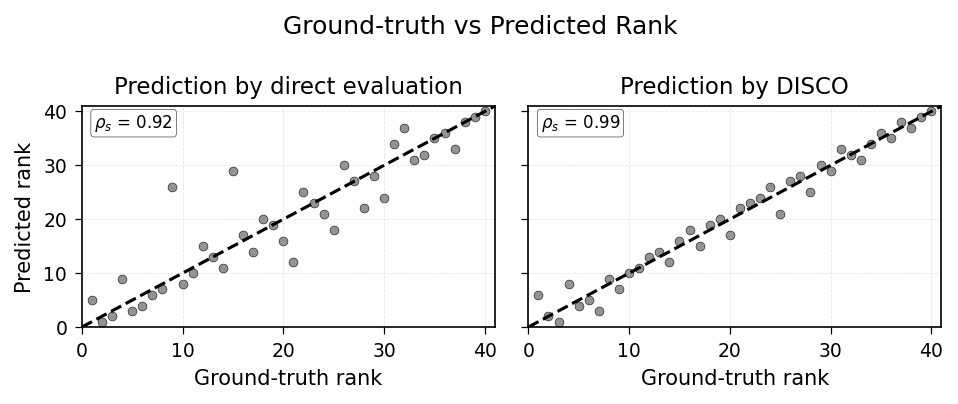

In [32]:
plot_rank_correlation_two(
    y_true=gt,
    y_pred_a=bad_preds,
    y_pred_b=good_predicted,
    model_a_name="Prediction by direct evaluation",
    model_b_name="Prediction by DISCO",
    tie_method="average",
    annotate_stats=True,
    pdf_path="sbs_rank.pdf",
)